# Zmiany semantyczne słów

<img src="https://live.staticflickr.com/65535/54942563983_f3baea0eee_c.jpg" alt="Embedded Photo" width="776">

## Wstęp

Znaczenia słów w języku naturalnym zmieniają się wraz z czasem — jedne ewoluują stopniowo, inne przechodzą gwałtowne przesunięcia semantyczne. Dzięki dawnym korpusom tekstowym możliwe jest trenowanie modeli wektorowych, które uchwytują te historyczne różnice.

W tym zadaniu będziesz analizować **pretrenowane embeddingi (word2vec)** z dwóch różnych epok:
- **1900** — model wytrenowany wyłącznie na danych z początku XX wieku  
- **1990** — model wytrenowany na danych bliskich współczesności  

Te dwa modele zostały wytrenowane **całkowicie niezależnie**. Twoim zadaniem będzie wykorzystać te reprezentacje, aby zbudować klasyfikator określający, czy **znaczenie danego słowa uległo istotnej zmianie między rokiem 1900 a 1990**.

## Zadanie

Zbudujesz **klasyfikator binarny**, który dla zadanego słowa zwróci etykietę:

- **0 — słowo stabilne semantycznie**
- **1 — słowo, którego znaczenie się zmieniło**

Dostępne dane:
- `train.csv` — zbiór treningowy (słowo + etykieta)
- `valid.csv` — zbiór walidacyjny do lokalnego testowania
- `1900-vocab.pkl` oraz `1900-w.npy` — słownik i macierz embeddingów z 1900 roku  
- `1990-vocab.pkl` oraz `1990-w.npy` — analogiczny zestaw dla roku 1990  

Twoje zadanie polega na implementacji własnej metody w klasie `SemanticShiftModel`, a konkretnie metody:

```python
predict_change(words: List[str]) -> List[int in {0,1}]
```

## Jak liczymy wynik?

Do oceny Twojego rozwiązania wykorzystujemy **Balanced Accuracy**:

$$ \text{Balanced Accuracy} = \frac{1}{2}(\text{TPR} + \text{TNR}) $$

czyli średnią z czułości (TPR) i specyficzności (TNR).  
Jest to metryka odporna na niezbalansowane zbiory.

Zwracasz **twarde etykiety (0/1)**.

W notebooku znajduje się funkcja `evaluate_algorithm`, dzięki której przetestujesz swój model na `valid.csv`.

Za to zadanie możesz zdobyć pomiędzy 0 a 100 punktów. Wynik będzie skalowany liniowo w zależności od wartości Balanced Accuracy:

- **Balanced Accuracy ≤ 0.7**: 0 punktów.
- **Balanced Accuracy ≥ 0.87**: 100 punktów.
- **Wartości pomiędzy 0.7 a 0.87**: skalowane liniowo.

Wzór na wynik:  
$$
\text{Punkty} = 
\begin{cases} 
0 & \text{dla } \text{Balanced Accuracy} \leq 0.7 \\
100 \times \frac{\text{Balanced Accuracy} - 0.7}{0.87 - 0.7} & \text{dla } 0.7 < \text{Balanced Accuracy} < 0.87 \\
100 & \text{dla } \text{Balanced Accuracy} \geq 0.87
\end{cases}
$$

## Ograniczenia środowiska

Twój notebook będzie uruchamiany w warunkach:

- **bez dostępu do internetu**
- **CPU only** (brak GPU)
- Limit czasu wykonania notebooka i ewaluacji zbioru walidacyjnego: **5 minut**
- Dozwolone biblioteki:
  - `numpy`
  - `pandas`
  - `scikit-learn`
  - `matplotlib`
  - `tqdm`

Na platformie konkursowej flagę:

`FINAL_EVALUATION_MODE = False`

ustawimy automatycznie na `True`. W tym trybie notebook **nie pobiera danych z internetu**, a Twoja implementacja zostanie przetestowana na ukrytym zbiorze testowym.

## Co musisz oddać?

- **Ten notebook**, z **uzupełnioną klasą**:

```python
class SemanticShiftModel:
    def fit(self, train_df):
        ...
    def predict_change(self, words: List[str]) -> List[int]:
        ...
```

- Notebook musi wykonywać się od początku do końca bez błędów.
- Wynik Twojego modelu zostanie oceniony na ukrytym zbiorze testowym.

## Inicjalizacja środowiska

In [3]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI PODCZAS WYSYŁANIA ##########################

# Flaga: na platformie oceniającej ustawiana na True
FINAL_EVALUATION_MODE = False

import os, json, pickle, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

from sklearn.metrics import balanced_accuracy_score

np.random.seed(42)
random.seed(42)

DATA_DIR = Path('data')
EMB_DIR  = DATA_DIR / 'embeddings'
EMB_DIR.mkdir(parents=True, exist_ok=True)


## Pobieranie danych (tylko lokalnie)

In [ ]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI PODCZAS WYSYŁANIA ##########################

# Uwaga: Na platformie oceniającej internet jest wyłączony.
# Ten blok uruchamia się tylko lokalnie (gdy FINAL_EVALUATION_MODE == False).

GDRIVE_FILES = [
    ('1rUGgDZcpwRZ5sRHGxxEh2f7ZJ0DRVDPL', EMB_DIR / '1900-vocab.pkl'),
    ('1cYXPhghcawbMZ6vU2XyJUq7NOpBIKj5E', EMB_DIR / '1900-w.npy'),
    ('1ApLkBn2ylvLMKNlNtvkMVde6RxnLJolI', EMB_DIR / '1990-vocab.pkl'),
    ('1B3NLInA4Ty3lUaHNQgxtDTKJNtG0t0T1', EMB_DIR / '1990-w.npy'),
    ('1hrOfZOq3BV1K0tWe6HSZG-OiZkGlCiYT', DATA_DIR / 'train.csv'),
    ('1vndyCuDCBP6zLvNkF_YsKHgTQgulTjt_', DATA_DIR / 'valid.csv'),
]

def download_data():
    try:
        import gdown
    except Exception as e:
        raise RuntimeError('Please install gdown locally: `pip install gdown`') from e

    DATA_DIR.mkdir(parents=True, exist_ok=True)
    EMB_DIR.mkdir(parents=True, exist_ok=True)

    for fid, out_path in GDRIVE_FILES:
        if out_path.exists():
            print(f'Skipping download, file already exists: {out_path.name}')
            continue
        url = f'https://drive.google.com/uc?id={fid}'
        out_path.parent.mkdir(parents=True, exist_ok=True)
        print(f'Downloading -> {out_path.name}')
        gdown.download(url, str(out_path), quiet=False)

if not FINAL_EVALUATION_MODE:
    download_data()
    print('Download complete.')
else:
    print('FINAL_EVALUATION_MODE=True — pomijam pobieranie (na platformie dane są dostarczone).')

## Ładowanie embeddingów i zbiorów danych

In [5]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI PODCZAS WYSYŁANIA ##########################

def load_histwords_decade(decade: int, emb_dir: Path):
    vocab_path = emb_dir / f'{decade}-vocab.pkl'
    w_path     = emb_dir / f'{decade}-w.npy'
    with open(vocab_path, 'rb') as f:
        vocab = pickle.load(f)
    W = np.load(w_path)
    # L2 normalize
    W = W / (np.linalg.norm(W, axis=1, keepdims=True) + 1e-12)
    w2i = {w:i for i,w in enumerate(vocab)}
    return vocab, W, w2i

# Load embeddings
vocab_1900, W1900, w2i_1900 = load_histwords_decade(1900, EMB_DIR)
vocab_1990, W1990, w2i_1990 = load_histwords_decade(1990, EMB_DIR)

print(f'1900: V={len(vocab_1900):,}, dim={W1900.shape[1]}')
print(f'1990: V={len(vocab_1990):,}, dim={W1990.shape[1]}')

# Load train/valid
train_path = DATA_DIR / 'train.csv'
valid_path = DATA_DIR / 'valid.csv'
# test_path = DATA_DIR / 'test.csv'
assert train_path.exists() and valid_path.exists(), 'train.csv / valid.csv not found in data/'

train_df = pd.read_csv(train_path)
valid_df = pd.read_csv(valid_path)
# test_df = pd.read_csv(test_path)

# Expect columns: word,label
for c in ['word', 'label']:
    assert c in train_df.columns and c in valid_df.columns, 'Expected columns: word,label'

train_df['word'] = train_df['word'].astype(str).str.lower().str.strip()
valid_df['word'] = valid_df['word'].astype(str).str.lower().str.strip()
# test_df['word'] = test_df['word'].astype(str).str.lower().str.strip()
train_df['label'] = train_df['label'].astype(int)
valid_df['label'] = valid_df['label'].astype(int)
# test_df['label'] = test_df['label'].astype(int)

print(train_df.head(5))
print()
print(valid_df.head(5))

print(f'train: {len(train_df)}, valid: {len(valid_df)}')

1900: V=100,000, dim=300
1990: V=100,000, dim=300
        word  label
0     lichen      0
1    imaging      1
2      devil      0
3    prayers      0
4  frankfort      1

        word  label
0  coastline      0
1       yoke      0
2     report      1
3   language      0
4       barn      0
train: 2495, valid: 832


In [6]:
def print_neighbors(word, V, vocab, w2i, label):
    vec = V[w2i[word]]
    sims = V @ vec
    sims[w2i[word]] = -np.inf
    top = np.argsort(-sims)[:10]
    print(f"\nTop 10 neighbors in {label}:")
    for i in top:
        print(f"  {vocab[i]}  ({sims[i]:.4f})")

print_neighbors("frankfort", W1900, vocab_1900, w2i_1900, "1900")
print_neighbors("frankfort", W1990, vocab_1990, w2i_1990, "1990")


Top 10 neighbors in 1900:
  mannheim  (0.4496)
  munich  (0.4368)
  budapest  (0.4340)
  1545  (0.4324)
  hamburg  (0.4314)
  buda  (0.4223)
  cologne  (0.4222)
  leipzig  (0.4208)
  zurich  (0.4199)
  augsburg  (0.4121)

Top 10 neighbors in 1990:
  piraeus  (0.4138)
  1097  (0.3696)
  fronting  (0.3682)
  ky  (0.3681)
  699  (0.3656)
  1320  (0.3643)
  1206  (0.3631)
  barnwell  (0.3561)
  4900  (0.3527)
  1550  (0.3507)


# Modelowe rozwiązanie

Poniższe rozwiązanie przechodzi przez cały proces uczenia maszynowego, od eksploracji danych po ewaluację modelu na zbiorze walidacyjnym.
Jako klasyfikator wykorzystano ensemble modeli HistGradientBoosting oraz Regresji Logistycznej.
Do uzyskania dobrych wyników wymagane jest stworzenie odpowiednich cech, które pozwolą na przewidywanie, czy dane słowo zmieniło swoje znaczenie.

Rozwiązanie zostało podzielone na poszczególne kroki:

* [1. Eksploracja danych](#1.-Eksploracja-danych)
  * [1.1 Podstawowe informacje](#1.1-Podstawowe-informacje)
  * [1.2 Walidacja danych](#1.2-Walidacja-danych)
  * [1.3 Transformacja danych](#1.3-Transformacja-danych)
    * [1.3.1 Embeddingi diachroniczne](#1.3.1-Embeddingi-diachroniczne)
    * [1.3.2 Wybór stabilnych punktów odniesienia](#1.3.2-Wybór-stabilnych-punktów-odniesienia)
    * [1.3.3 Wyrównanie przestrzeni metodą Prokrustesa](#1.3.3-Wyrównanie-przestrzeni-metodą-Prokrustesa)
* [2. Inżynieria cech](#2.-Inżynieria-cech)
  * [2.1 Odległości bezpośrednie (First Order Similarity)](#2.1-Odległości-bezpośrednie)
  * [2.2 Profile podobieństwa drugiego rzędu (Second Order Similarity)](#2.2-Profile-podobieństwa-drugiego-rzędu)
  * [2.3 Zróżnicowane zestawy kotwic](#2.3-Zróżnicowane-zestawy-kotwic)
  * [2.4 Analiza przetasowań rankingowych (Rank Distance)](#2.4-Analiza-przetasowań-rankingowych)
* [3. Architektura modelu (Stacking Ensemble)](#3.-Architektura-modelu)
  * [3.1 Modele bazowe: HistGradientBoosting i Regresja Logistyczna](#3.1-Modele-bazowe)
  * [3.2 Meta-klasyfikator i agregacja prawdopodobieństw](#3.2-Meta-klasyfikator-i-agregacja-prawdopodobieństw)
* [4. Klasa SemanticChangeModel](#4.-Klasa-SemanticChangeModel)
* [5. Cykl uczenia i ewaluacji](#5.-Cykl-uczenia-i-ewaluacji)
  * [5.1 Trening z wykorzystaniem Out-of-Fold (OOF)](#5.1-Trening-z-wykorzystaniem-Out-of-Fold)
  * [5.2 Optymalizacja progu decyzyjnego](#5.2-Optymalizacja-progu-decyzyjnego)
  * [5.3 Wyniki na zbiorze walidacyjnym (Balanced Accuracy)](#5.3-Wyniki-na-zbiorze-walidacyjnym)

## 1. Eksploracja danych
Zanim przejdziemy do implementacji klasyfikatora, zaczniemy od eksploracji danych. Jest to kluczowa część rozwiązywania każdego problemu z zakresu uczenia maszynowego. Eksploracyjna analiza danych (EDA) pozwala na zrozumienie danych treningowych, ich walidację oraz korektę ewentualnych braków i szumów w nich zawartych.

### 1.1 Podstawowe informacje
Zaczynamy od sprawdzenia ogólnych właściwości dostępnych zbiorów danych. Obejmuje to sprawdzenie właściwości takich jak: liczba obserwacji, liczba cech, brakujące wartości.

W przypadku tego zadania, do dyspozycji mamy zestawy danych dotyczące dwóch różnych epok (1900 i 1990). Konkretnie:
- `train.csv` — zbiór treningowy (słowo + etykieta)
- `valid.csv` — zbiór walidacyjny do lokalnego testowania
- `1900-vocab.pkl` oraz `1900-w.npy` — słownik i macierz embeddingów z 1900 roku  
- `1990-vocab.pkl` oraz `1990-w.npy` — analogiczny zestaw dla roku 1990 

In [7]:
# sprawdzenie ilości obserwacji w zbiorze treningowym i walidacyjnym
print(f'Liczba obserwacji w zbiorze treningowym: {len(train_df)}')
print(f'Liczba obserwacji w zbiorze walidacyjnym: {len(valid_df)}')

# sprawdzenie rozmiaru słownika dla obu lat
print(f'Rozmiar słownika 1900: {len(vocab_1900)}')
print(f'Rozmiar słownika 1990: {len(vocab_1990)}')

# sprawdzenie długości wektorów osadzeń
print(f'Długość wektorów osadzeń 1900: {W1900.shape[1]}')
print(f'Długość wektorów osadzeń 1990: {W1990.shape[1]}')

Liczba obserwacji w zbiorze treningowym: 2495
Liczba obserwacji w zbiorze walidacyjnym: 832
Rozmiar słownika 1900: 100000
Rozmiar słownika 1990: 100000
Długość wektorów osadzeń 1900: 300
Długość wektorów osadzeń 1990: 300


In [8]:
# sprawdzenie braku danych w zbiorach treningowym i walidacyjnym
print(f'Liczba brakujących wartości w zbiorze treningowym:\n{train_df.isnull().sum()}')
print(f'Liczba brakujących wartości w zbiorze walidacyjnym:\n{valid_df.isnull().sum()}')

Liczba brakujących wartości w zbiorze treningowym:
word     0
label    0
dtype: int64
Liczba brakujących wartości w zbiorze walidacyjnym:
word     0
label    0
dtype: int64


In [9]:
# Przykładowe dane
print(train_df.head(5))

        word  label
0     lichen      0
1    imaging      1
2      devil      0
3    prayers      0
4  frankfort      1


### 1.2 Walidacja danych

Po wstępnej eskploracji podstawowych właściwości danych, przeprowadzimy walidację danych treningowych i walidacyjnych, aby upewnić się, że są one odpowiednie do dalszej analizy i modelowania. Weryfikację obejmują:
- Porównanie rozkładów zmiennej celu w zbiorach danych
- Sprawdzenie obecności słów z obu zbiorów danych w obu słownikach (1900 i 1990)

In [10]:
# porównanie rozkładów zmiennej celu w zbiorze treningowym i walidacyjnym
print(f'Rozkład zmiennej celu w zbiorze treningowym:\n{train_df["label"].value_counts(normalize=True)}')
print(f'Rozkład zmiennej celu w zbiorze walidacyjnym:\n{valid_df["label"].value_counts(normalize=True)}')

Rozkład zmiennej celu w zbiorze treningowym:
label
0    0.569138
1    0.430862
Name: proportion, dtype: float64
Rozkład zmiennej celu w zbiorze walidacyjnym:
label
0    0.569712
1    0.430288
Name: proportion, dtype: float64


Rozkłady zmiennej docelowej są bardzo zbliżone dla siebie dla zbioru treningowego i walidacyjnego, co jest zdecydowanie pożądane.

Proporcja klasy pozytywnej do negatywnej jest nieznaczenie niezbilansowana i wynosi około 57% do 43%. Warto o tym pamiętać przy budowaniu klasyfikatora binarnego.

In [11]:
# Sprawdzenie nieobecności słów ze zbioru treningowego i walidacyjnego w słownikach dla obu lat
train_words_missing_1900 = (~train_df['word'].isin(w2i_1900)).sum()
train_words_missing_1990 = (~train_df['word'].isin(w2i_1990)).sum()
valid_words_missing_1900 = (~valid_df['word'].isin(w2i_1900)).sum()
valid_words_missing_1990 = (~valid_df['word'].isin(w2i_1990)).sum()

print(f'Liczba słów ze zbioru treningowego BRAKUJĄCYCH w słowniku 1900: {train_words_missing_1900}')
print(f'Liczba słów ze zbioru treningowego BRAKUJĄCYCH w słowniku 1990: {train_words_missing_1990}')
print(f'Liczba słów ze zbioru walidacyjnego BRAKUJĄCYCH w słowniku 1900: {valid_words_missing_1900}')
print(f'Liczba słów ze zbioru walidacyjnego BRAKUJĄCYCH w słowniku 1990: {valid_words_missing_1990}')


# Sprawdzenie czy maksymalny indeks w słowniku odpowiada rozmiarowi macierzy embeddingów
max_index_1900 = max(w2i_1900.values()) + 1 # dodajemy 1, bo indeksy zaczynają się od 0
max_index_1990 = max(w2i_1990.values()) + 1
print(f'Max indeks w słowniku 1900 (licząc od 1): {max_index_1900}, rozmiar macierzy embeddingów: {W1900.shape[0]}')
print(f'Max indeks w słowniku 1990 (licząc od 1): {max_index_1990}, rozmiar macierzy embeddingów: {W1990.shape[0]}')

Liczba słów ze zbioru treningowego BRAKUJĄCYCH w słowniku 1900: 0
Liczba słów ze zbioru treningowego BRAKUJĄCYCH w słowniku 1990: 0
Liczba słów ze zbioru walidacyjnego BRAKUJĄCYCH w słowniku 1900: 0
Liczba słów ze zbioru walidacyjnego BRAKUJĄCYCH w słowniku 1990: 0
Max indeks w słowniku 1900 (licząc od 1): 100000, rozmiar macierzy embeddingów: 100000
Max indeks w słowniku 1990 (licząc od 1): 100000, rozmiar macierzy embeddingów: 100000


Wszystkie słowa ze zbiorów treningowego i walidacyjnego są obecne w słownikach, a także rozmiar słowników odpowiada macierzy embeddingów, co gwarantuje nam, że każde słowo w danych ma odpowiadający mu wektor w przestrzeni słów z roku 1900 oraz 1990.

Zobaczmy jeszcze, jak **poglądowo** wyglądają słowa jako punkty w przestrzeniach 1900 i 1990. Do tego posłużymy się metodą [t-SNE (t-Distributed Stochastic Neighbor Embedding)](https://en.wikipedia.org/wiki/T-distributed_stochastic_neighbor_embedding) -  to nieliniowa technika redukcji wymiarowości, która wizualizuje dane wielowymiarowe w przestrzeni dwu- lub trzywymiarowej, grupując podobne punkty danych w skupiska, co ułatwia ich eksplorację, analizę i zrozumienie struktury zbioru danych.

c:\Users\48601\anaconda3\envs\zmiany_semantyczne\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


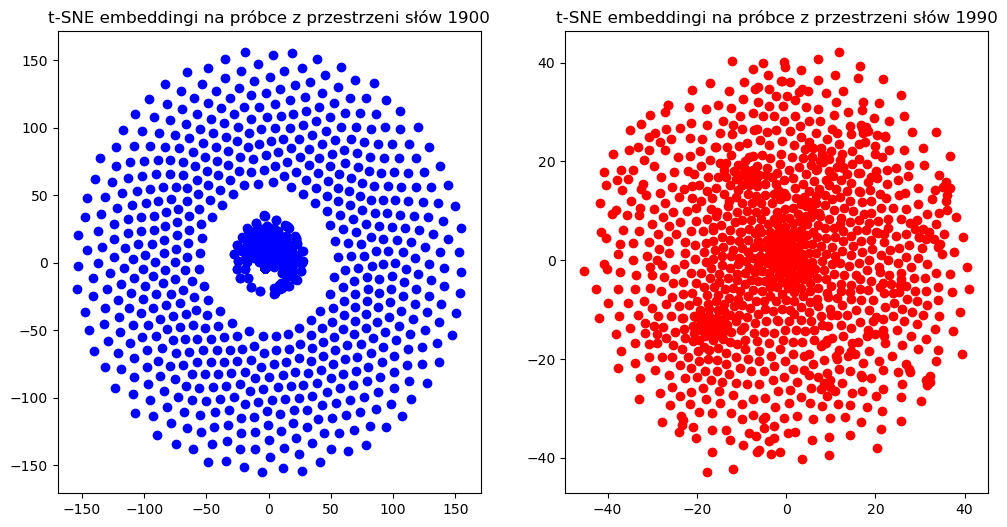

In [12]:
# Wizualizacja wektorów osadzeń dla losowo wybranych słów z obu lat za pomocą t-SNE
from sklearn.manifold import TSNE

rng = np.random.default_rng(42)
sample_words = rng.choice(list(train_df['word']), size=1000, replace=False).tolist() # wybieramy 1000 losowych słów z zbioru treningowego
embeddings_1900 = np.array([W1900[w2i_1900[word]] for word in sample_words if word in w2i_1900])
embeddings_1990 = np.array([W1990[w2i_1990[word]] for word in sample_words if word in w2i_1990])
tsne_1900 = TSNE(n_components=2, random_state=42).fit_transform(embeddings_1900)
tsne_1990 = TSNE(n_components=2, random_state=42).fit_transform(embeddings_1990)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(tsne_1900[:, 0], tsne_1900[:, 1], color='blue')
plt.title('t-SNE embeddingi na próbce z przestrzeni słów 1900')
plt.subplot(1, 2, 2)
plt.scatter(tsne_1990[:, 0], tsne_1990[:, 1], color='red')
plt.title('t-SNE embeddingi na próbce z przestrzeni słów 1990')
plt.show()

Warto zwrócić uwagę na różnice w strukturze lokalnej obu przestrzeni. W roku 1900 rozkład punktów wydaje się bardziej równomierny i rozproszony, co może sugerować mniejszą polaryzację semantyczną badanej próbki słów. Z kolei na wykresie z roku 1990 obserwujemy tendencję do tworzenia wyraźniejszych, gęstszych skupisk (klastrów). Może to wskazywać na silniejszą kategoryzację pojęć lub powstanie specyficznych nisz kontekstowych w nowszym korpusie.

Skale osi na obu wykresach są różne, co jest typowe dla algorytmu t-SNE i wynika z jego stochastycznej natury oraz braku zachowania globalnych odległości. Same wartości na osiach nie niosą informacji o skali podobieństwa słów, dlatego nie należy ich ze sobą bezpośrednio zestawiać. 

Należy pamiętać, że porównujemy **dwie niezależnie stworzone** przestrzenie wektorowe. Bez transformacji przestrzeni embeddingów, wszelkie porównania między tymi dwiema przestrzeniami mają charakter poglądowy. O potrzebnych przekształceniach danych mowa w następnej sekcji.

### 1.3 Transformacja danych

Proces transformacji jest krytycznym etapem przygotowania danych w zadaniu wykrywania zmian semantycznych. Ponieważ porównujemy dwa oddzielne modele wektorowe word2vec (trenowane niezależnie na korpusach z różnych epok), nie możemy bezpośrednio zestawić ich współrzędnych bez wcześniejszego sprowadzenia ich do wspólnego układu odniesienia.

Problem polega na tym, że wektory (współrzędne słów) z roku 1900 i 1990 są zapisane w dwóch zupełnie innych „językach matematycznych”. Nawet jeśli słowo w ogóle nie zmieniło znaczenia, jego współrzędne w obu tabelach będą inne. Musimy je do siebie dopasować, zanim zaczniemy jakiekolwiek porównania.

#### 1.3.1 Embeddingi diachroniczne
Embeddingi diachroniczne to reprezentacje wektorowe słów, które przechwytują ich znaczenie w konkretnych przedziałach czasowych. W niniejszym zadaniu operujemy na dwóch przestrzeniach: $W_{1900}$ oraz $W_{1990}$.

Kluczowym wyzwaniem jest brak zmienności w różnych przestrzeniach. Oznacza to, że nawet jeśli znaczenie słów nie uległoby zmianie, ich wektory w dwóch różnych treningach mogą być względem siebie obrócone lub przesunięte. Dlatego pierwszym krokiem jest zrozumienie, że różnica w surowych współrzędnych nie jest miarą zmiany semantycznej, lecz zależy od procesu trenowania modeli.

#### 1.3.2 Wybór stabilnych punktów odniesienia
Aby móc dopasować dwie przestrzenie, musimy zidentyfikować punkty stałe (***kotwice***) – słowa o których wiemy, że na pewno nie zmieniły swojej pozycji (są stabilne semantycznie).

Proces selekcji kotwic przebiega następująco:
- Wybieramy tylko słowa stabilne, które występują w słownikach obu epok.
- Ze względów wydajnościowych i aby zapobiec nadmiernemu dopasowaniu do szumu, w finalnym rozwiązaniu ograniczamy liczbę kotwic do $N=400$.
- Jeśli dostępnych jest więcej słów stabilnych, wybieramy ich podzbiór drogą losową, co zapewnia modelowi stabilną "bazę porównawczą" rozproszoną w różnych obszarach przestrzeni semantycznej.

Kotwice posłużą jako „pinezki”, które pozwolą nam nałożyć jedną mapę na drugą. Jeśli dobrze dopasujemy pinezki, to każda różnica w położeniu innych słów będzie już wynikać z ich realnej zmiany znaczenia, a nie z obrotu mapy.

In [13]:
# Wybieramy słowa stabilne (label 0)
stable_words = train_df[train_df['label'] == 0]['word'].tolist()
common_anchors = [i for i in range(len(stable_words)) if stable_words[i] in w2i_1900 and stable_words[i] in w2i_1990]
anchor_idx_1900 = [w2i_1900[stable_words[i]] for i in common_anchors]
anchor_idx_1990 = [w2i_1990[stable_words[i]] for i in common_anchors]

#### 1.3.3 Wyrównanie przestrzeni metodą Prokrustesa

Najważniejszym elementem transformacji jest Ortogonalny Problem Prokrustesa (Orthogonal Procrustes Problem). Jest to metoda znalezienia optymalnej macierzy rotacji $R$, która zminimalizuje sumę kwadratów odległości między wektorami kotwic w obu przestrzeniach. Wykorzystamy tę metodę w oparciu o wykorzystanie jej w literaturze ([Hamilton et. al., 2016](https://arxiv.org/pdf/1605.09096)).

Matematycznie szukamy macierzy $R$, która spełnia warunek:
$$R = \arg\min_{\Omega} \| \Omega A - B \|_F \quad \text{przy warunku ortogonalności} \quad \Omega^T\Omega = I$$
gdzie $A$ i $B$ to macierze wektorów kotwic odpowiednio z lat 1990 i 1900, a $\| \cdot \|_F$ to norma Frobeniusa.

Implementacja opiera się na [rozkładzie według wartości osobliwych (SVD)](https://pl.wikipedia.org/wiki/Rozk%C5%82ad_wed%C5%82ug_warto%C5%9Bci_osobliwych). Autorzy powyższej publikacji powołują się na zasadność tej metody, jako że daje najlepsze możliwe przekształcenie liniowe na podstawie wcześniejszczego artykułu ([Schoenemann, 1966](https://web.stanford.edu/class/cs273/refs/procrustes.pdf)). Znalezienie przekształcenia przebiega w następujący sposób:
1. Obliczamy iloczyn macierzowy $M = B^T A$ po uprzedniej normalizacji L2 obu macierzy $A$ i $B$.
2. Wykonujemy dekompozycję $SVD(M) = U \Sigma V^T$.
3. Optymalna macierz rotacji to $R = U V^T$.

**Intuicyjnie**, możemy to rozumieć, że metoda Prokrustesa szuka takiej macierzy (operacji obrotu), która zminimalizuje błąd dopasowania:

1. **Iloczyn macierzy:** Najpierw sprawdzamy, jak wektory kotwic z jednej epoki są rozmieszczone względem swoich odpowiedników z drugiej.
2. **Dopasowanie (SVD):** Zamiast ręcznie szukać parametrów przekształcenia, stosujemy dekompozycję SVD. Rozkłada ona te relacje na czynniki pierwsze, dostarczając precyzyjnej instrukcji: „obróć przestrzeń tak, aby zminimalizować błąd dopasowania”.
3. **Efekt:** Po zastosowaniu wyznaczonej macierzy rotacji, obie przestrzenie znajdują się w tym samym układzie odniesienia.

Po wyznaczeniu $R$, cała macierz $W_{1990}$ zostaje przekształcona ($W_{1990} \times R$), co pozwala na bezpośrednie obliczanie dystansu cosinusowego między wektorami z obu epok. Na koniec obie macierze poddawane są **normalizacji L2**. To sprawia, że długość każdego wektora wynosi dokładnie 1. Dzięki temu wszystkie słowa zostają rzutowane na powierzchnię tej samej sfery, a jedyną rzeczą, która nas interesuje, jest kąt między nimi (im mniejszy kąt, tym bardziej podobne słowa).

**Dlaczego to działa?** Skuteczność tej metody opiera się na założeniu, że przestrzenie embeddingów słów są izomorficzne – co oznacza, że ich wewnętrzna struktura relacji pozostaje trwała w czasie, a zmienia się jedynie orientacja układu współrzędnych. Zastosowanie rotacji ortogonalnej (zamiast pełnego przekształcenia afinicznego) jest optymalne, ponieważ jako izometria zachowuje ona niezmienniczość iloczynów skalarnych, na których opiera się semantyka modelu word2vec. Przekształcenie afiniczne (zawierające translację czyli przesunięcie każdego elementu przestrzeni o stałą) mogłoby zniekształcić strukturę przestrzeni, gdyż przesunięcie wektorów o stały wektor średniej zmienia kąty między nimi w sposób nieliniowy. Dodatkowo, translacja przesuwa naturalny środek układu ($[0, \dots, 0]^T$), co pozbawia model sensu semantycznego – w procesie treningu SGNS (Skip-gram z negative sampling) wektory są naturalnie centrowane wokół zera. Kluczowym aspektem jest zatem wymóg ortogonalności ($\Omega^T\Omega = I$), który gwarantuje zachowanie odległości cosinusowych i chroni oryginalne relacje semantyczne przed sztuczną deformacją.

In [14]:
def normalize(X):
    """Funkcja pomocnicza do normalizacji L2 wektorów osadzeń."""
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return X / norms

# 1.3.3 Wyrównanie przestrzeni metodą Prokrustesa
def procrustes_align(W_src: np.ndarray, W_tgt: np.ndarray, words_list: list[str], w2i_src: dict[str, int], w2i_tgt: dict[str, int]) -> np.ndarray:
    """Wyrównanie przestrzeni źródłowej W_src do przestrzeni docelowej W_tgt za pomocą metody Prokrustesa."""
    # 1. Wybranie tylko wspólnych wektorów kotwic i normalizacja
    anchors_src = normalize(np.vstack([W_src[w2i_src[w]] for w in words_list]))
    anchors_tgt = normalize(np.vstack([W_tgt[w2i_tgt[w]] for w in words_list]))
    
    # 2. Obliczenie macierzy korelacji (Cross-correlation matrix): M = B^T @ A (według wzoru z opisu)
    M = anchors_tgt.T @ anchors_src
    
    # 3. Rozkład SVD
    U, _, Vt = np.linalg.svd(M)
    
    # 4. Wyznaczenie optymalnej rotacji R = U @ Vt
    R = U @ Vt
    
    # 5. Przekształcenie całej przestrzeni źródłowej z normalizacją L2
    W_src_aligned = normalize(W_src @ R.T)
    
    return W_src_aligned


# Wykonujemy wyrównanie (upraszczając do tych samych indeksów co w 1.3.2 dla czytelności przykładu)
W1990_aligned = procrustes_align(W1990, W1900, stable_words, w2i_1990, w2i_1900)
# Normalizacja macierzy źródłowych aby porównanie dystansów było bardziej miarodajne
W_1900_norm = normalize(W1900)
W_1990_norm = normalize(W1990)

# Wizualizacja efektu: Porównanie pozycji przykładowego pierwszego stabilnego słowa w dwóch przestrzeniach
sample_word = train_df[train_df['label'] == 0]['word'].iloc[0]
idx_1900 = w2i_1900[sample_word]
idx_1990 = w2i_1990[sample_word]

print(f"Słowo: {sample_word}, dystans pomiędzy reprezentacjami w przestrzeniach 1900 i 1990:")
print(f"Dystans przed wyrównaniem: {np.linalg.norm(W_1900_norm[idx_1900] - W_1990_norm[idx_1990]):.4f}")
print(f"Dystans po wyrównaniu: {np.linalg.norm(W_1900_norm[idx_1900] - W1990_aligned[idx_1990]):.4f}")

Słowo: lichen, dystans pomiędzy reprezentacjami w przestrzeniach 1900 i 1990:
Dystans przed wyrównaniem: 1.1939
Dystans po wyrównaniu: 0.9065


## 2. Inżynieria cech

Po procesie wyrównania przestrzeni, każde słowo reprezentowane jest przez dwa wektory w tym samym układzie współrzędnych. Celem tego etapu jest przekształcenie par wektorów w zestaw cech, które odzwierciedlają różnego rodzaju przesunięcia semantyczne.
Inżynieria cech to kluczowy krok w całym rozwiązaniu, ponieważ od jakości stworzonych cech w znacznym stopniu zależy finalny wynik. W kolejnych podrozdziałach przyjrzymy się kolejnym grupom cech, jakie można było wykorzystać w tym zadaniu.

### 2.1 Odległości bezpośrednie
Najbardziej intuicyjną miarą zmiany znaczenia jest geometryczna odległość między reprezentacją słowa w roku 1900 a jego odpowiednikiem w roku 1990. Wykorzystujemy dwie powszechne miary: 

- **Cosine Similarity (Podobieństwo Cosinusowe)**: Miara kątowa między wektorem słowa z 1900 r. a wyrównanym wektorem z 1990 r. Wykrywa ona zmianę kierunku wektora, co świadczy o zmianie kontekstów użycia. Wyliczana jest w następujący sposób:
$$\text{cosine\_sim}(\mathbf{u}, \mathbf{v}) = \frac{\mathbf{u} \cdot \mathbf{v}}{\|\mathbf{u}\| \|\mathbf{v}\|} = \frac{\sum_{i=1}^{n} u_i v_i}{\sqrt{\sum_{i=1}^{n} u_i^2} \sqrt{\sum_{i=1}^{n} v_i^2}}$$
Żeby być precyzyjnym, w naszym rozwiązaniu wykorzystamy ***odległość cosinusową (Cosine Distance)***, którą wyliczamy bezpośrednio na podstawie cosine similarity jako:
$$\text{cosine\_distance}(\mathbf{u}, \mathbf{v}) = 1 - \text{cosine\_sim}(\mathbf{u}, \mathbf{v})$$

- **L2 Distance (Odległość Euklidesowa)**: Geometryczny dystans między punktami w przestrzeni. W przypadku znormalizowanych wektorów, cecha ta jest skorelowana z miarą cosinusową, ale pozwala modelowi na wychwycenie subtelniejszych różnic w położeniu punktów:
$$\text{euclidean\_dist}(\mathbf{u}, \mathbf{v}) = \|\mathbf{u} - \mathbf{v}\|_2 = \sqrt{\sum_{i=1}^{n} (u_i - v_i)^2}$$

Cechy First-order Similarity mierzą globalne przesunięcie.

In [15]:
# obliczanie dystansu cosinusowego i euklidesowego dla tych samych słów w obu przestrzeniach embeddingów na przykładzie losowo wybranego słowa
word = random.choice(train_df['word'].tolist())
v1, v2 = W1900[w2i_1900[word]], W1990[w2i_1990[word]]
cosine_distance = 1 - np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
euclidean_distance = np.linalg.norm(v1 - v2)
print(f'Dystans cosinusowy dla słowa "{word}": {cosine_distance:.4f}')
print(f'Dystans euklidesowy dla słowa "{word}": {euclidean_distance:.4f}')

Dystans cosinusowy dla słowa "hats": 0.5579
Dystans euklidesowy dla słowa "hats": 1.0563


### 2.2 Profile podobieństwa drugiego rzędu

Podejście to zakłada, że znaczenie słowa jest definiowane nie przez jego pozycję w próżni, ale przez jego relację do stabilnych punktów odniesienia w języku. Nawet jeśli globalne wyrównanie przestrzeni metodą Prokrustesa nie jest idealne, profile SOS pozwalają na precyzyjną analizę lokalną.

Cechy te są znacznie bardziej odporne na szum, ponieważ nie bazują na surowych współrzędnych, lecz na relacjach. Słowo może wykazywać niewielkie przesunięcie geometryczne, ale jeśli jego hierarchia podobieństwa względem stabilnych pojęć uległa rekonfiguracji (np. słowo „komórka” zbliżyło się do „telefonu”, a oddaliło od „biologii”), profil Second Order Similarity wychwyci tę zmianę kontekstową, której globalny dystans cosinusowy mógłby nie doszacować.

Do porównania profili wykorzystujemy następujące cechy:

- **Second-Order Cosine Distance**: Model buduje profil podobieństwa słowa do stabilnych kotwic w 1900 r. i analogiczny profil w 1990 r. Następnie liczy odległość cosinusową między tymi dwoma profilami.

- **Second-Order L2 Distance**: Dystans euklidesowy między wektorami profilowymi.

In [16]:
# Budowa profilu relacji względem stabilnych słów - na przykładzie pierwszych 5 stabilnych słów-sond (probe words)

# Wybór 5 stabilnych słów jako sondy (kotwice)
stable_probes = train_df[train_df['label'] == 0]['word'].head(5).tolist()
probe_idx1 = [w2i_1900[w] for w in stable_probes]
probe_idx2 = [w2i_1990[w] for w in stable_probes]

# Pobranie wektorów sond
probes_v1 = W1900[probe_idx1]
probes_v2 = W1990_aligned[probe_idx2]

# Wybór badanego słowa (np. pierwszego z brzegu)
test_word = train_df['word'].iloc[0]
v1 = W1900[w2i_1900[test_word]]
v2 = W1990_aligned[w2i_1990[test_word]]

# Profil SOS: podobieństwo badanego słowa do każdej z 5 sond
sos_profile1 = v1.dot(probes_v1.T)
sos_profile2 = v2.dot(probes_v2.T)

print("profil SOS dla słowa '{}':".format(test_word))
sos_df = pd.DataFrame({
    'probe_word': stable_probes,
    'podobienstwo_profilu_1900': sos_profile1,
    'podobienstwo_profilu_1990': sos_profile2
})
print(sos_df)

profil SOS dla słowa 'lichen':
  probe_word  podobienstwo_profilu_1900  podobienstwo_profilu_1990
0     lichen                   1.000000                   1.000000
1      devil                  -0.065169                   0.023794
2    prayers                  -0.028219                  -0.000271
3   eyebrows                   0.130505                   0.123314
4  streaming                   0.230388                   0.092982


### 2.3 Zróżnicowane zestawy kotwic

Aby uzyskać wielowymiarowy obraz zmiany, nie polegamy na jednym punkcie odniesienia, lecz analizujemy zachowanie słowa względem różnych warstw słownictwa. W modelu zdefiniowano kilka zestawów kotwic:
* Zestawy częstotliwościowe (Top 100, 500, 1000): Reprezentują najbardziej stabilny rdzeń języka.
* Zestawy losowe: Pozwalają na uchwycenie korelacji z mniej oczywistymi, rzadszymi obszarami semantycznymi.

Różne słowa zmieniają znaczenie w różny sposób – jedne uciekają od kontekstów potocznych, inne od technicznych. Analiza statystyk (średnia, mediana, odchylenie standardowe) na wielu grupach kotwic pozwala modelowi na uśrednienie błędów i stabilizację predykcji.

Dla każdego zestawu kotwic (np. Top 100 najczęstszych, Top 500, zestaw losowy) obliczane są:
* **Delta Sim (Różnica podobieństwa)**: Wartość $$|\text{Sim}(w, anchor)_{1990} - \text{Sim}(w, anchor)_{1900}|$$ gdzie $\text{Sim}$ to operacja mnożenia macierzowego (dot product): $\text{Sim}(X, Y) = X \cdot Y^T$.
* Statystyki agregujące dla każdego zestawu:
    - ***Średnia (Mean)***: Przeciętna zmiana podobieństwa do wszystkich kotwic w danym zestawie.
    - ***Odchylenie standardowe (Std)***: Informuje, czy słowo zmieniło się równomiernie względem wszystkich kotwic, czy tylko wobec niektórych.
    - ***Mediana*** i ***Max***: Pozwalają wyłapać ekstremalne przesunięcia semantyczne, które mogłyby zostać "rozmyte" przez średnią.

In [17]:
# Przykład - pobieramy pierwsze 50 słów z modelu jako demonstracyjny zestaw kotwic
anchors_idx = np.arange(50)
a1 = W1900[anchors_idx]
a2 = W1990_aligned[anchors_idx]

# Podobieństwo badanego słowa do całego zestawu kotwic
sims1 = v1.dot(a1.T)
sims2 = v2.dot(a2.T)

# Różnica bezwzględna (delta)
adiff = np.abs(sims2 - sims1)

# Agregacja do cech (np. średnia zmiana względem kotwic)
anchor_feature_mean = adiff.mean()
print(f"Średnia zmiana podobieństwa względem kotwic: {anchor_feature_mean:.4f}")

Średnia zmiana podobieństwa względem kotwic: 0.0703


### 2.4 Analiza przetasowań rankingowych
Jest to najbardziej zaawansowana cecha modelu, która abstrahuje od surowych wartości podobieństwa na rzecz struktury sąsiedztwa. Dla każdego zestawu kotwic model sortuje je według podobieństwa do badanego słowa, tworząc ranking. Następnie obliczamy, o ile pozycji w tym rankingu przesunęła się każda kotwica między rokiem 1900 a 1990.

Wartości podobieństwa cosinusowego mogą ulegać zmianie ze względu na różną wielkość korpusów treningowych. Jednak hierarchia pojęć jest zazwyczaj trwalsza. **Intuicyjnie**, jeśli słowo „zamek” w 1900 roku miało w pierwszej dziesiątce sąsiadów słowo „król”, a w 1990 „król” spadł na 500. miejsce w rankingu, otrzymujemy bardzo silny, nieparametryczny dowód na zmianę semantyczną (tzw. rank displacement).

Wykorzystywane cechy to:

* **Rank Displacement (Przesunięcie w rankingu)**: Dla każdej kotwicy z danego zestawu model sprawdza, jaką pozycję zajmowała ona na liście najbliższych sąsiadów słowa w 1900 r., a jaką w 1990 r. (np. w 1900 r. kotwica była 2. najbliższym sąsiadem, a w 1990 r. spadła na 40. miejsce).

* **Statystyki Rankingu**:
    - ***Mean Rank Displacement***: Średnie przetasowanie całej listy sąsiadów.
    - ***Std Rank Displacement***: Zmienność przetasowań.
    - ***Median & Max Rank Displacement***: Maksymalny "skok" pozycji w rankingu, co jest bardzo silnym sygnałem zmiany znaczenia (np. nagłe pojawienie się nowego, dominującego znaczenia).

In [18]:
# Sortowanie indeksów kotwic według podobieństwa (od największego) wykorzystując przykład z 2.3
# argsort zwraca pozycje, które posortowałyby tablicę
rank1 = np.argsort(-sims1) # pozycje kotwic w 1900
rank2 = np.argsort(-sims2) # pozycje kotwic w 1990

# Obliczamy, na której pozycji w rankingu znalazła się każda kotwica
pos1 = np.argsort(rank1)
pos2 = np.argsort(rank2)

# Odległość rankingowa dla każdej kotwicy
rank_distances = np.abs(pos1 - pos2)

print(f"Średni Rank Distance (przesunięcie w rankingu): {rank_distances.mean():.2f}")

Średni Rank Distance (przesunięcie w rankingu): 14.56


## 3. Architektura modelu

Finalna decyzja klasyfikacyjna nie jest podejmowana przez pojedynczy algorytm, lecz przez ensemble modeli zorganizowany w architekturę typu Stacking. Podejście to opiera się na założeniu, że różne rodziny algorytmów uczą się różnych aspektów danych: modele drzewiaste doskonale radzą sobie z wykrywaniem progów i nieliniowości, podczas gdy modele liniowe lepiej wychwytują ogólne trendy.

### 3.1 Modele bazowe
W pierwszej warstwie naszego ensemblu modeli działają dwa niezależne klasyfikatory bazowe, które przetwarzają wektor cech wyekstrahowany w poprzednim kroku:

* **HistGradientBoostingClassifier (HGB)**: Jest to nowoczesna implementacja drzew decyzyjnych wzmacnianych gradientem. Jej głównym zadaniem jest identyfikacja złożonych zależności między cechami. HGB potrafi wychwycić, że np. zmiana w rankingu (Rank Distance) powyżej pewnego progu, połączona z niską odległością cosinusową, jest silniejszym sygnałem zmiany niż każda z tych cech z osobna.

* **Regresja Logistyczna (LR)**: Pełni rolę stabilizatora ensemblu. Jako model liniowy, wyznacza optymalną hiperpłaszczyznę oddzielającą słowa zmienne od stabilnych. Jest mniej podatna na przeuczenie (overfitting) w sytuacjach, gdzie dane są niejednoznaczne, co zapewnia modelowi lepszą generalizację na słowach, których nie było w zbiorze treningowym.

### 3.2 Meta-klasyfikator i agregacja prawdopodobieństw
Druga warstwa architektury to tzw. meta-klasyfikator, który pełni rolę arbitra podejmującego ostateczną decyzję na podstawie "opinii" wypracowanych przez modele bazowe.

* Agregacja predykcji: Modele bazowe nie przekazują meta-klasyfikatorowi gotowych etykiet (0 lub 1), lecz surowe prawdopodobieństwa (predict_proba). Dzięki temu zachowana zostaje informacja o pewności (lub niepewności) każdego z modeli co do danej obserwacji.

* Rola Meta-klasyfikatora (Logistic Regression): Meta-klasyfikator uczy się optymalnie ważyć odpowiedzi modeli bazowych, identyfikując, który z nich statystycznie rzadziej myli się przy danej kombinacji predykcji. Pozwala to na skuteczną kalibrację pewności siebie algorytmów i kompensację ich indywidualnych tendencji do błędów, bez konieczności ponownej analizy surowych cech.

* Zaleta ensemblu: Tak skonstruowany ensemblu jest znacznie bardziej odporny na błędy indywidualne poszczególnych algorytmów. Łączy on wysoką zdolność predykcyjną modeli gradientowych ze stabilnością i prostotą modeli statystycznych, co bezpośrednio przekłada się na wyższy wynik Balanced Accuracy.

In [19]:
# Załóżmy, że X to macierz cech wygenerowana dla słów w train_df
# Tutaj symulujemy ją na podstawie rozmiaru train_df i 12 cech
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression


X = np.random.rand(len(train_df), 12) 
y = train_df['label'].values

# Modele bazowe trenowane na realnych etykietach
hgb = HistGradientBoostingClassifier().fit(X, y)
lr = LogisticRegression(max_iter=1000).fit(X, y)

# Meta-cechy: prawdopodobieństwa z modeli bazowych
meta_X = np.column_stack([
    hgb.predict_proba(X)[:, 1],
    lr.predict_proba(X)[:, 1]
])

# Meta-klasyfikator uczący się jak łączyć te wyniki
meta_clf = LogisticRegression().fit(meta_X, y)

print(f"Symulowane prawdopodobieństwo zmiany (Meta) dla pierwszego słowa ze zbioru treningowego ({train_df['word'].iloc[0]}): {meta_clf.predict_proba(meta_X[:1])[:, 1][0]:.4f}")

Symulowane prawdopodobieństwo zmiany (Meta) dla pierwszego słowa ze zbioru treningowego (lichen): 0.0333


### 4. Klasa `SemanticChangeModel`
Klasa SemanticChangeModel stanowi serce całego rozwiązania. Została zaprojektowana jako spójny interfejs integrujący wszystkie opisane wcześniej etapy: od geometrycznego wyrównania przestrzeni, przez wielopoziomową ekstrakcję cech, aż po wnioskowanie z wykorzystaniem ensemblu modeli.

Dzięki hermetyzacji logiki wewnątrz jednej klasy, proces wykrywania zmian semantycznych staje się powtarzalny i odporny na błędy implementacyjne, a sam model jest zgodny z paradygmatem scikit-learn (wykorzystanie metod `fit` i `predict`).

Skład i struktura klasy
Struktura klasy została podzielona na moduły odpowiedzialne za stan modelu, transformacje oraz klasyfikację:

- Stan i parametry:

    * *W1900* / *W1990_aligned*: Macierze wektorowe reprezentujące oba stany języka. Po wywołaniu metody fit, macierz z 1990 roku jest przechowywana już w formie wyrównanej.

    * Anchor Sets: Kolekcja zestawów indeksów (częstotliwościowych i losowych), które służą jako punkty odniesienia dla cech drugiego rzędu.

    * Probe Indices: Zbiór słów uznanych za absolutnie stabilne, wykorzystywany do budowy profili podobieństwa SOS.

- Metody pomocnicze:

    * `_normalize_rows()`: Statyczna metoda dbająca o to, by wszystkie operacje wektorowe odbywały się na sferze jednostkowej, co jest kluczowe dla poprawności dystansu cosinusowego.

    * `_align_spaces()`: Metoda wykonująca wyrównanie przestrzeni metodą Prokrustesa - począwszy od wyboru słów stabilnych, przez rozkład SVD, po rzutowanie macierzy $W_{1990}$ i normalizację obu macierzy.

    * `_extract_features()`: Najbardziej rozbudowana metoda klasy. Agreguje ona informacje z odległości bezpośrednich, statystyk podobieństwa względem kotwic oraz różnic w rankingach sąsiedztwa.

- Ensemble decyzyjny:

    * `self.clf_hgb` / `self.clf_lr`: Dwa modele bazowe (drzewiasty i liniowy), które analizują wyekstrahowane cechy niezależnie od siebie.

    * `self.clf_meta`: Model nadrzędny, który uczy się optymalnej wagi głosów modeli bazowych.

    * `self.scaler`: Standaryzator, który zapewnia, że cechy o różnych skalach (np. mały dystans cosinusowy vs duże przesunięcie w rankingu) mają jednakowy wpływ na proces uczenia.

- Trening i inferencja:

    * `fit()`: Realizuje pełny proces treningowy: wyznacza rotację Prokrustesa na słowach stabilnych, generuje cechy dla zbioru uczącego i przeprowadza trening ensemblu z wykorzystaniem techniki Out-of-Fold.

    * `predict_change()`: Metoda końcowa, która dla podanej listy słów generuje cechy, przesyła je przez ensemblu i zwraca binarną decyzję (0 lub 1) w oparciu o zoptymalizowany próg decyzyjny.


### 5. Cykl uczenia i ewaluacji

Proces trenowania modelu `SemanticChangeModel` został zaprojektowany tak, aby maksymalnie wykorzystać dostępne dane treningowe przy jednoczesnym uniknięciu przeuczenia (*overfitting*). Kluczowym elementem jest tutaj synchronizacja procesu inżynierii cech z wieloetapowym nauczaniem ensemblu klasyfikatorów.

#### 5.1 Trening z wykorzystaniem Out-of-Fold

Aby meta-klasyfikator (Regresja Logistyczna) mógł nauczć się optymalnego ważenia głosów modeli bazowych, nie może on oceniać ich pracy na danych, które te modele już widziały. W tym celu zastosowaliśmy technikę **Out-of-Fold** (OOF) w ramach 5-krotnej walidacji krzyżowej (`StratifiedKFold`):

1. **Podział danych:** Zbiór treningowy dzielony jest na 5 podzbiorów.
2. **Uczenie rotacyjne:** W każdej iteracji modele bazowe (HGB i LR) trenowane są na 4 podzbiorach, a następnie generują prawdopodobieństwa dla pozostałego, 5. podzbioru (którego nie widziały podczas treningu).
3. **Budowa cech meta:** Po zakończeniu 5 iteracji dysponujemy „czystymi” predykcjami dla całego zbioru treningowego. Te prawdopodobieństwa stają się cechami wejściowymi dla meta-klasyfikatora.

#### 5.2 Optymalizacja progu decyzyjnego

Standardowe modele klasyfikacji binarnej przyjmują próg odcięcia na poziomie $0.5$. Jednak w zadaniu wykrywania zmian semantycznych, gdzie klasy są nieznacznie niezbalansowane ($57\%$ słów stabilnych do $43\%$ zmienionych), próg ten został poddany optymalizacji w celu maksymalizacji metryki `Balanced Accuracy`.

* **Próg $0.57$**: Został wyznaczony eksperymentalnie jako punkt, w którym model najlepiej wypada dla obu klas. Podniesienie progu powyżej standardowego $0.5$ sprawia, że klasyfikator staje się bardziej konserwatywny w przypisywaniu etykiety pozytywnej.
* **Uzasadnienie**: Taka kalibracja pozwala odfiltrować szum wynikający z drobnych zmian wektorowych, które nie reprezentują realnej zmiany semantycznej, a jedynie specyfikę treningu modelu word2vec. Dzięki temu model oznacza słowo jako zmienione tylko wtedy, gdy sygnał płynący z ensemblu modeli jest wystarczająco silny, by przeważyć naturalną tendencję do stabilności języka.

#### 5.3 Wyniki na zbiorze walidacyjnym

Ostateczna ewaluacja modelu odbywa się z wykorzystaniem metryki `Balanced Accuracy`, która jest kluczowa ze względu na nierównomierny rozkład klas (zazwyczaj znacznie więcej słów jest stabilnych niż zmiennych).

* **Agregacja wiedzy:** Dzięki architekturze ensemblu, model skutecznie koryguje błędy. Jeśli HistGradientBoosting przeszacuje prawdopodobieństwo zmiany ze względu na specyficzny układ cech w danej fałdzie, Regresja Logistyczna (jako model stabilniejszy liniowo) często koryguje ten wynik, sprowadzając go poniżej progu decyzyjnego.
* **Obsługa braków:** Model posiada wbudowany mechanizm *fallback* – słowa, których brakuje w słownikach jednej z epok, są automatycznie klasyfikowane jako zmienione, co odzwierciedla intuicję, że całkowite wyjście słowa z użycia (lub jego pojawienie się) jest ekstremalną formą zmiany semantycznej.

In [20]:
#########################  ZMODYFIKUJ TYLKO TĘ KOMÓRKĘ  #########################
# Zaimplementuj swój model jako klasę z metodami:
#   - __init__       : zapisz osadzenia (embeddings) + podstawowe hiperparametry
#   - fit(train_df)  : trenuj na oznaczonych danych
#   - predict_change(words) : zwróć etykiety dla podanej listy słów
#
# Kod ewaluacyjny otrzyma instancję klasy i będzie zakładał jedynie, że posiada
# metodę .predict_change(words).
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold


class SemanticChangeModel:
    """
    Model wykrywający zmiany semantyczne przy użyciu wyrównania Prokrustesa,
    cech first-order i second-order similarity oraz ensemblu klasyfikatorów.
    """

    def __init__(self, W1900: np.ndarray, W1990: np.ndarray, w2i_1900: dict[str, int], w2i_1990: dict[str, int],
                 random_anchor_n = 400,
                 freq_anchor_sizes = (100, 500, 1000),
                 stable_anchor_n = 400,
                 random_state = 42):
        
        # [1.3.1 Charakterystyka embeddingów diachronicznych] - Inicjalizacja surowych przestrzeni
        self.W1900 = np.asarray(W1900, dtype=np.float32)
        self.W1990 = np.asarray(W1990, dtype=np.float32)
        self.w2i_1900 = dict(w2i_1900)
        self.w2i_1990 = dict(w2i_1990)
        self.random_state = random_state

        # [1.3.2 Wybór stabilnych punktów odniesienia] - Parametry doboru kotwic
        self.random_anchor_n = int(random_anchor_n)
        self.freq_anchor_sizes = tuple(int(x) for x in freq_anchor_sizes)
        self.stable_anchor_n = int(stable_anchor_n)

        self.W1990_aligned = None
        self.anchor_sets = []
        self.probe_indices1900 = None
        self.probe_indices1990 = None

        # [3.1 Modele bazowe: HistGradientBoosting i Regresja Logistyczna]
        self.scaler = StandardScaler()
        self.clf_hgb = HistGradientBoostingClassifier(
            max_iter=500, l2_regularization=1.0, random_state=self.random_state
        )
        self.clf_lr = LogisticRegression(
            class_weight='balanced', max_iter=2000, random_state=self.random_state
        )
        # [3.2 Meta-klasyfikator i agregacja prawdopodobieństw]
        self.clf_meta = LogisticRegression(random_state=self.random_state)

    @staticmethod
    def _normalize_rows(X: np.ndarray) -> np.ndarray:
        """Normalizacja L2 wierszy macierzy."""
        norms = np.linalg.norm(X, axis=1, keepdims=True)
        norms[norms == 0] = 1.0
        return X / norms

    def _align_spaces(self, train_df: pd.DataFrame):
        """Wyrównanie przestrzeni wektorowych metodą Prokrustesa"""
        words = list(train_df['word'])
        labels = list(train_df['label'])

        # [1.3.2 Wybór stabilnych punktów odniesienia] - Filtrowanie słów z etykietą 0
        stable_words = [
            w for w, lbl in zip(words, labels)
            if lbl == 0 and w in self.w2i_1900 and w in self.w2i_1990
        ]

        rng = np.random.default_rng(self.random_state)
        if len(stable_words) > self.stable_anchor_n:
            stable_words = rng.choice(stable_words, size=self.stable_anchor_n, replace=False).tolist()

        # Przygotowanie macierzy do SVD
        a_vecs = np.vstack([self.W1990[self.w2i_1990[w]] for w in stable_words])
        b_vecs = np.vstack([self.W1900[self.w2i_1900[w]] for w in stable_words])

        # [1.3.3 Wyrównanie przestrzeni metodą Prokrustesa (Alignment)]
        u, _, vt = np.linalg.svd(
            (self._normalize_rows(b_vecs).T @ np.conjugate(self._normalize_rows(a_vecs))).T
        )
        rotation_matrix = u @ vt

        # Rzutowanie przestrzeni 1990 na 1900
        self.W1990_aligned = (self.W1990 @ rotation_matrix).astype(np.float32)
        # Normalizacja obu przestrzeni po wyrównaniu
        self.W1900 = self._normalize_rows(self.W1900)
        self.W1990_aligned = self._normalize_rows(self.W1990_aligned)

        # Zapamiętanie indeksów do cech SOS (probe indices)
        self.probe_indices1900 = np.array([self.w2i_1900[w] for w in stable_words])
        self.probe_indices1990 = np.array([self.w2i_1990[w] for w in stable_words])

        # Przygotowanie zestawów kotwic (losowych i na bazie częstotliwości)
        v_size = min(self.W1900.shape[0], self.W1990_aligned.shape[0])
        self.anchor_sets.append(rng.choice(v_size, size=min(self.random_anchor_n, v_size), replace=False))
        for n in self.freq_anchor_sizes:
            if min(n, v_size) > 0:
                self.anchor_sets.append(np.arange(min(n, v_size), dtype=int))

    def _extract_features(self, words: list[str]) -> tuple[np.ndarray, np.ndarray]:
        """[2. Inżynieria cech] - Generowanie cech zmiany semantycznej."""
        valid_mask = np.array([w in self.w2i_1900 and w in self.w2i_1990 for w in words], dtype=bool)
        valid_words = [w for w, is_valid in zip(words, valid_mask) if is_valid]

        idx1 = np.array([self.w2i_1900[w] for w in valid_words])
        idx2 = np.array([self.w2i_1990[w] for w in valid_words])

        v1, v2 = self.W1900[idx1], self.W1990_aligned[idx2]

        # [2.1 Odległości bezpośrednie (First-order features)]
        cos_dist = 1.0 - np.sum(v1 * v2, axis=1)
        l2_dist = np.linalg.norm(v1 - v2, axis=1)

        # [2.2 Profile podobieństwa drugiego rzędu (SOS)]
        probe_v1 = self.W1900[self.probe_indices1900]
        probe_v2 = self.W1990_aligned[self.probe_indices1990]
        so_v1 = self._normalize_rows(v1.dot(probe_v1.T))
        so_v2 = self._normalize_rows(v2.dot(probe_v2.T))
        so_cos_dist = 1.0 - np.sum(so_v1 * so_v2, axis=1)
        so_l2_dist = np.linalg.norm(so_v1 - so_v2, axis=1)

        anchor_feats_list = []
        for anchors in self.anchor_sets:
            a1, a2 = self.W1900[anchors], self.W1990_aligned[anchors]
            sims1, sims2 = v1.dot(a1.T), v2.dot(a2.T)
            
            # [2.3 Zestawy kotwic] - Statystyki różnic podobieństwa
            delta = sims2 - sims1
            adiff = np.abs(delta)

            # [2.4 Analiza przetasowań rankingowych (Rank Distance)]
            r1 = np.argsort(-sims1, axis=1)
            r2 = np.argsort(-sims2, axis=1)
            pos1 = np.argsort(r1, axis=1)
            pos2 = np.argsort(r2, axis=1)
            rd = np.abs(pos1 - pos2)

            fset = np.vstack([
                adiff.mean(axis=1), adiff.std(axis=1), np.median(adiff, axis=1), adiff.max(axis=1),
                rd.mean(axis=1), rd.std(axis=1), np.median(rd, axis=1), rd.max(axis=1),
            ]).T
            anchor_feats_list.append(fset)

        base_feats = np.vstack([cos_dist, l2_dist, so_cos_dist, so_l2_dist]).T
        x_valid = np.hstack([base_feats] + anchor_feats_list)

        x_full = np.zeros((len(words), x_valid.shape[1]), dtype=np.float32)
        x_full[valid_mask] = x_valid
        return x_full, valid_mask

    def fit(self, train_df: pd.DataFrame):
        """Trening ensemblu za pomocą Stacking (HGB + LR -> Meta LR)."""
        self._align_spaces(train_df)

        train_words_df = train_df[train_df['word'].isin(self.w2i_1900) & train_df['word'].isin(self.w2i_1990)]
        x, _ = self._extract_features(train_words_df['word'].tolist())
        y = train_words_df['label'].values

        xs = self.scaler.fit_transform(x)

        # [5.1 Trening z wykorzystaniem Out-of-Fold (OOF)]
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=self.random_state)
        meta_features = np.zeros((len(y), 2))

        for train_idx, test_idx in skf.split(xs, y):
            xs_train, xs_test = xs[train_idx], xs[test_idx]
            y_train = y[train_idx]

            self.clf_hgb.fit(xs_train, y_train)
            self.clf_lr.fit(xs_train, y_train)
            meta_features[test_idx, 0] = self.clf_hgb.predict_proba(xs_test)[:, 1]
            meta_features[test_idx, 1] = self.clf_lr.predict_proba(xs_test)[:, 1]

        # [5.2 Optymalizacja progu decyzyjnego] - na podstawie balansu klas
        self.threshold = 1.0 - train_df['label'].mean()

        self.clf_meta.fit(meta_features, y)
        self.clf_hgb.fit(xs, y)
        self.clf_lr.fit(xs, y)

    def predict_change(self, words: list[str]) -> list[int]:
        """[5.3 Wyniki na zbiorze walidacyjnym] - Predykcja finalna."""
        x_full, valid_mask = self._extract_features(words)
        xs = self.scaler.transform(x_full)

        p_hgb = self.clf_hgb.predict_proba(xs)[:, 1]
        p_lr = self.clf_lr.predict_proba(xs)[:, 1]
        meta_input = np.vstack([p_hgb, p_lr]).T
        p_final = self.clf_meta.predict_proba(meta_input)[:, 1]

        preds = (p_final >= self.threshold).astype(int)
        preds[~valid_mask] = 1  # Fallback dla brakujących słów
        return preds.tolist()
    
MODEL = SemanticChangeModel(W1900, W1990, w2i_1900, w2i_1990)
MODEL.fit(train_df)

## Ewaluacja

In [21]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI PODCZAS WYSYŁANIA ##########################
def compute_score(bal_acc: float) -> float:
    """
    Oblicza wynik punktowy na podstawie wartości zbalansowanej dokładności.

    :param bal_acc: Wartość float w zakresie [0.0, 1.0]
    :return: Wynik punktowy zgodny z określoną funkcją
    """
    if bal_acc <= 0.7:
        return 0
    elif 0.7 < bal_acc < 0.87:
        return int(round(100 * (bal_acc - 0.7) / (0.87 - 0.7)))
    else:
        return 100


def evaluate_algorithm(dataset_df, model, verbose=False):
    """
    Ewaluacja modelu wykrywania zmiany znaczenia słów na podanym zbiorze danych.

    Parametry
    ----------
    dataset_df : pd.DataFrame
        Oznaczony zbiór danych z kolumnami:
          - 'word'  : słowo (string)
          - 'label' : etykieta 0 = stabilne, 1 = zmienione

    model : obiekt
        Obiekt posiadający metodę:
            predict_change(words: list[str]) -> list[int] {0,1}

    verbose : bool
        Jeśli True, wypisuje dodatkowe informacje.

    Zwraca
    -------
    points : float
        Wynik punktowy oparty na zbalansowanej dokładności.
    """

    # Extract words and labels from the dataset
    words = dataset_df["word"].astype(str).tolist()
    ys = dataset_df["label"].astype(int).tolist()

    # Get predictions for the entire list of words
    preds = model.predict_change(words)

    # Convert predictions and labels to numpy arrays
    preds = np.array(preds, dtype=np.int32)
    ys = np.array(ys, dtype=np.int32)

    # Balanced accuracy
    bal_acc = balanced_accuracy_score(ys, preds)

    # Convert accuracy to contest points
    points = compute_score(bal_acc)

    if verbose:
        print(f"\nLiczba próbek: {len(dataset_df)}")
        print(f"Balanced accuracy: {bal_acc:.4f}")
        print(f"Wynik punktowy: {points}")

    return points


# Local validation example
if not FINAL_EVALUATION_MODE:
    _ = evaluate_algorithm(valid_df, MODEL, verbose=True)


Liczba próbek: 832
Balanced accuracy: 0.8716
Wynik punktowy: 100
